<a href="https://colab.research.google.com/github/Philly-KJR/Assignment2/blob/main/Kalik_Reece_Assignment4_STAT53894_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# STAT53894 – Assignment 4

## Medical Insurance Cost Dataset Analysis

**Student Name:** Kalik Reece

**Deliverable:** Download this Jupyter Notebook and upload to the **Assignment 4** dropbox. You can submit as many times as youn want, but just the last submission will be kept and marked.

**[Assignment Policy](https://courses.ghassem.com/docs/policies/college-assignments.html)**

In this assignment, you will analyze the Medical Insurance Cost Dataset to build regression and classification models.

## Overview

Dataset: Medical Insurance Cost

Link: https://raw.githubusercontent.com/tofighi/dataset/refs/heads/main/machine-learning/insurance.csv

Target Variables:
- Regression: `charges`
- Classification: `smoker`

## Task 0: Import Libraries and Load Dataset (Done!)

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, precision_recall_curve
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import statsmodels.api as sm

# Set visualization style
plt.style.use('default')
sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the dataset
url = "https://raw.githubusercontent.com/tofighi/dataset/refs/heads/main/machine-learning/insurance.csv"
df = pd.read_csv(url)

# Display basic information
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nDataset Info:")
df.info()

print("\nSummary Statistics:")
display(df.describe())

Dataset Shape: (1338, 7)

First 5 rows:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

Summary Statistics:


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## Task 1: Exploratory Data Analysis

**Your codes here**

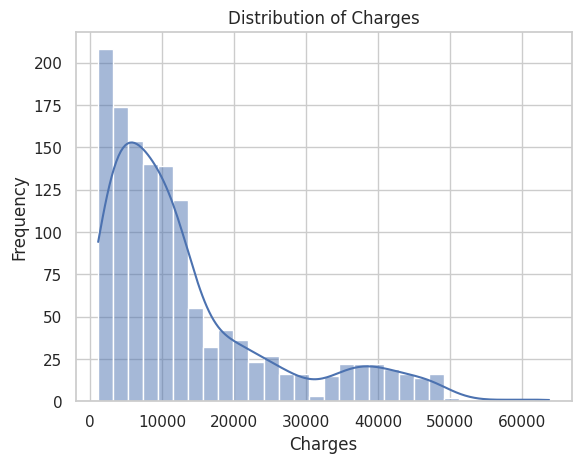

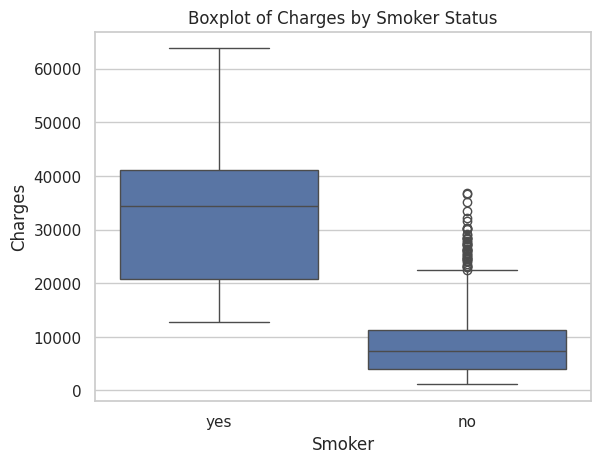

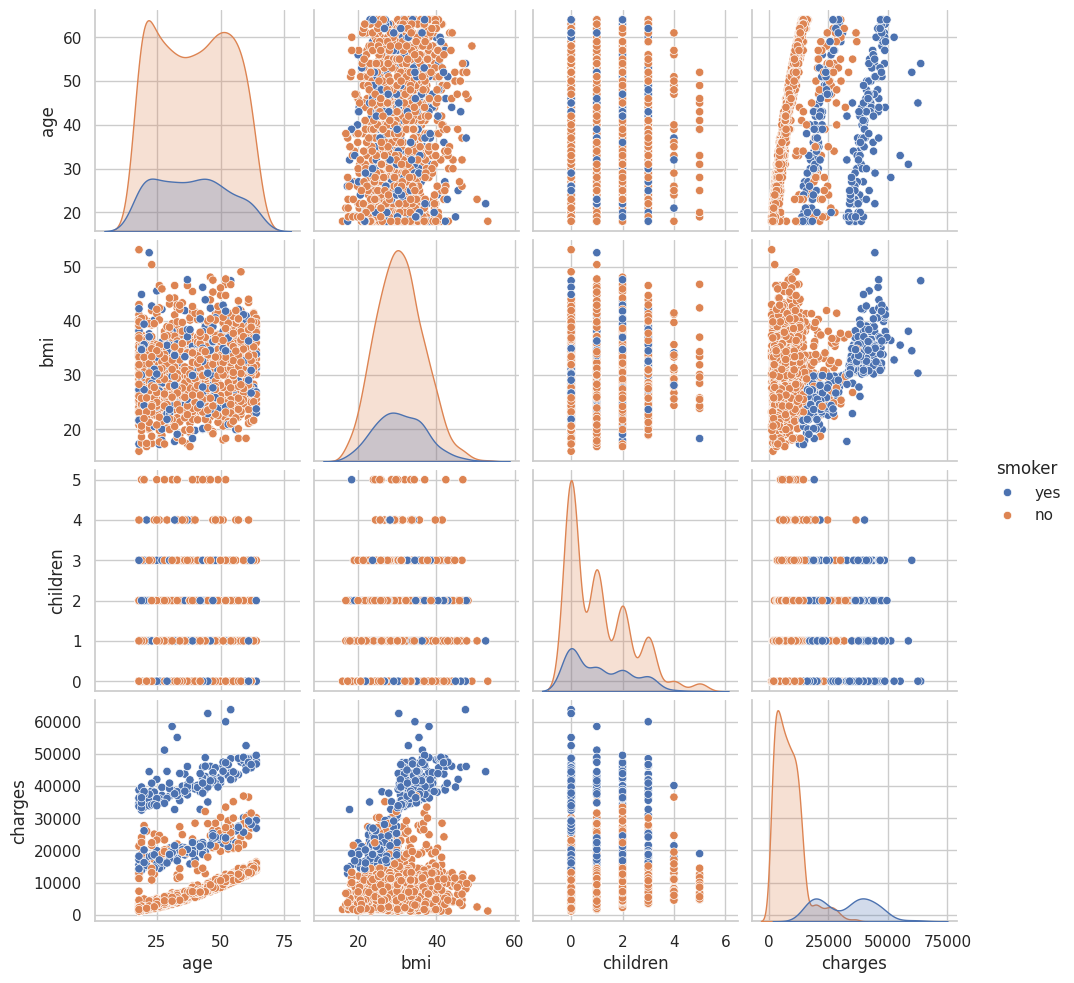

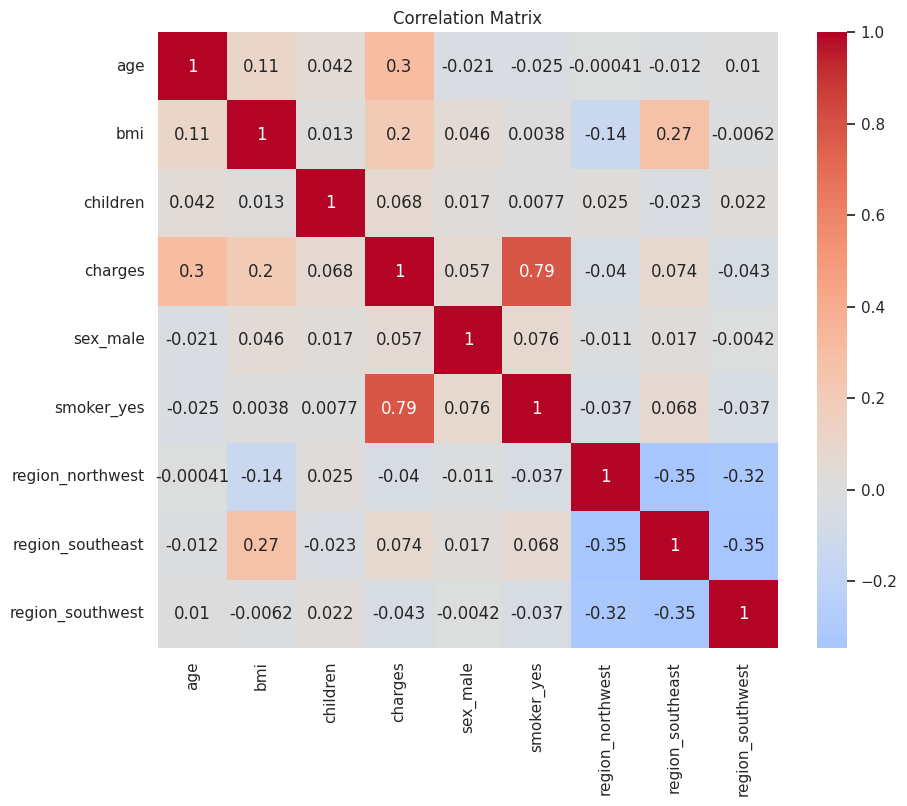

In [3]:
# Your codes here for EDA (distributions, correlations, etc.)

# Example placeholder:

#Create a histogram of the 'charges' column to understand its distribution
sns.histplot(df['charges'], kde=True)
plt.title('Distribution of Charges')
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.show()

#Crate a boxplot to visualize the distribution of charges based on smoker status. See if there are any outliers or differences in charges between smokers and non-smokers.
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Boxplot of Charges by Smoker Status')
plt.xlabel('Smoker')
plt.ylabel('Charges')
plt.show()

#Create a pairplot to visualize the relationships between numerical features and color by smoker status. This will help identify any patterns or correlations between features.
sns.pairplot(df, hue='smoker')
plt.show()

#Convert categorical columns to numeric for correlation analysis
df_corr = df.copy()
df_corr = pd.get_dummies(df_corr, drop_first=True)

# Calculate the correlation matrix
corr_matrix = df_corr.corr()

# Visualize the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()



## Task 2: Linear Regression & Interpretation

**Model Development**: Build a Multiple Linear Regression model to predict `charges`.

In [4]:
# Your codes here
# 1. Preprocess data (encode categorical variables: sex, smoker, region)
# Answer: already done above using pd.get_dummies and stored in df_corr

# 2. Split data into train/test
X = df_corr.drop('charges', axis=1)
y = df_corr['charges']
X_train, X_test, y_train, y_test = train_test_split(
	X, y, test_size=0.2, random_state=42
)

# 3. Fit Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Make predictions and evaluate (R², RMSE)
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

#Show coefficients of the linear regression model
print("\nLinear Regression Coefficients:", [f"{coef:.4f}" for coef in model.coef_])

#Show the intercept of the linear regression model
print(f"\nIntercept: {model.intercept_:.4f}")

print("\nLinear Regression Model Evaluation:")
print(f"R²: {r2:.4f}")
print(f"RMSE: {rmse:.2f}")



Linear Regression Coefficients: ['256.9757', '337.0926', '425.2788', '-18.5917', '23651.1289', '-370.6773', '-657.8643', '-809.7994']

Intercept: -11931.2191

Linear Regression Model Evaluation:
R²: 0.7836
RMSE: 5796.28


**Interpretation Section**

- Interpret coefficients for top 3 predictors:
Answer: Looking at the heatmap the top 3 predictors are: smoker, BMI, and age.
- Explain the intercept: the intercept is -$11,931 which seems odd to have a negative charge value. However, the model is good with a score of 78% so they intercept does not matter as much.
- Report R-squared and RMSE: R^2 = 78.36% . A high R^2 shows the model is good.  However, the RMSE is also high which may indicate that there may be a better model available for this dataset.

## Task 3: Classification Model Comparison

Predict `smoker` using other features.

In [5]:
# Your codes here
# 1. Prepare features and target (smoker) — use the dummy column 'smoker_yes'
X_smoker = df_corr.drop('smoker_yes', axis=1)
y_smoker = df_corr['smoker_yes']

# 2. Train Logistic Regression, Naive Bayes, and LDA
model_logistic = LogisticRegression(max_iter=5000)
model_logistic.fit(X_smoker, y_smoker)

model_nb = GaussianNB()
model_nb.fit(X_smoker, y_smoker)

model_lda = LinearDiscriminantAnalysis()
model_lda.fit(X_smoker, y_smoker)

# 4. Evaluate each model and create comparison table
y_pred_logistic = model_logistic.predict(X_smoker)
y_pred_nb = model_nb.predict(X_smoker)
y_pred_lda = model_lda.predict(X_smoker)

print("\nLogistic Regression Evaluation:")
print(f"Accuracy: {accuracy_score(y_smoker, y_pred_logistic):.4f}")
print(classification_report(y_smoker, y_pred_logistic))

print("\nNaive Bayes Evaluation:")
print(f"Accuracy: {accuracy_score(y_smoker, y_pred_nb):.4f}")
print(classification_report(y_smoker, y_pred_nb))

print("\nLDA Evaluation:")
print(f"Accuracy: {accuracy_score(y_smoker, y_pred_lda):.4f}")
print(classification_report(y_smoker, y_pred_lda))


Logistic Regression Evaluation:
Accuracy: 0.9611
              precision    recall  f1-score   support

       False       0.99      0.97      0.98      1064
        True       0.88      0.95      0.91       274

    accuracy                           0.96      1338
   macro avg       0.93      0.96      0.94      1338
weighted avg       0.96      0.96      0.96      1338


Naive Bayes Evaluation:
Accuracy: 0.9028
              precision    recall  f1-score   support

       False       0.93      0.95      0.94      1064
        True       0.80      0.71      0.75       274

    accuracy                           0.90      1338
   macro avg       0.86      0.83      0.84      1338
weighted avg       0.90      0.90      0.90      1338


LDA Evaluation:
Accuracy: 0.9297
              precision    recall  f1-score   support

       False       0.95      0.96      0.96      1064
        True       0.83      0.82      0.83       274

    accuracy                           0.93      1338
  

**Model Comparison Table & Discussion**

Discuss assumptions and best fit.

After running all 3 models, logistic regression had the highest F1. This shows that both precision and recall are high.

## Task 4: Precision-Recall Evaluation

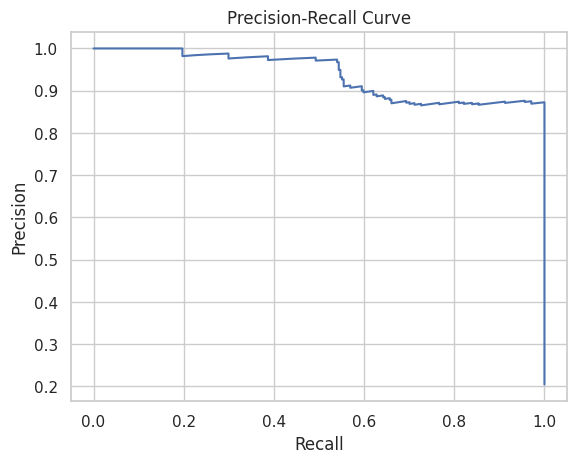

Optimal threshold: 0.4218


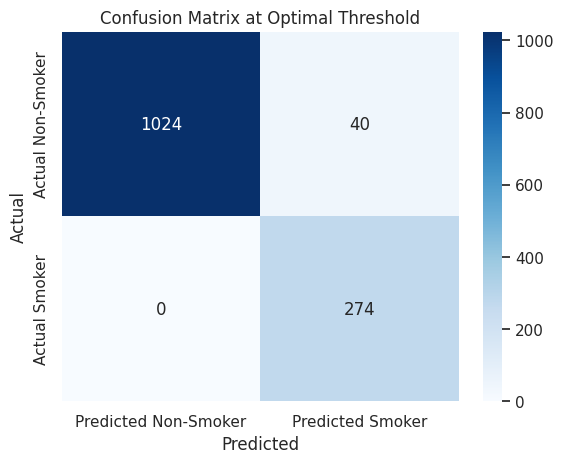


Confusion Matrix at Optimal Threshold:
[[1024   40]
 [   0  274]]


In [6]:
# Your codes here
# 1. Generate Precision-Recall Curve for best model
precision, recall, thresholds = precision_recall_curve(y_smoker, model_logistic.predict_proba(X_smoker)[:, 1])
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

# 2. Find optimal threshold
optimal_threshold = thresholds[np.argmax(precision[:-1] * recall[:-1])] #used Gemini for this coding
print(f"Optimal threshold: {optimal_threshold:.4f}")

# 3. Justify FP vs FN importance
# From a business perspective, false negatives (FN) are considered to be more important than false positives (FP). A false negative would mean that a smoker is incorrectly classified as a non-smoker.  Since smokers are generally associated with higher medical costs, this mistake may lead to underestimating insurance risk and could result in financial losses for the insurance company.
# On the other hand, a false positive would mean that a non-smoker is incorrectly classified as a smoker, which might lead to unnecessary concern but would be less critical. Therefore, we prioritize minimizing false negatives.

# Create Confusion Matrix for the best model at optimal threshold
from sklearn.metrics import confusion_matrix
y_pred_optimal = (model_logistic.predict_proba(X_smoker)[:, 1] >= optimal_threshold).astype(int)
matrix = confusion_matrix(y_smoker, y_pred_optimal)
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Non-Smoker', 'Predicted Smoker'], yticklabels=['Actual Non-Smoker', 'Actual Smoker'])
plt.title('Confusion Matrix at Optimal Threshold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
print("\nConfusion Matrix at Optimal Threshold:")
print(matrix)



## Task 5: Final Insights and Conclusions

This excercise was helpful in determining the best model for predicting smokers leveraging the dataset.  Logistic regression was the best as indicated by the F1 score and high level of accuracy.  We went on to further validate by using the precision-recall curve and finding the optimal threshold.  I added the confusion matrix to add a visual.  Actual false negatives were zero.  This aligned with the business priority of correctly identifing actual smokers.  

This was a fun excercise and I learned a lot about the linear and logistic regression analysis. Then using different methods to validate the data.